In [50]:
# ============================================================
# CELL 1: Imports and Unit Declarations
# Units: hbar = 1, m = 1  =>  k = sqrt(2E), kappa = sqrt(2(V0-E))
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma as Gamma
from scipy.integrate import quad
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# --- atomic units---
hbar = 1.0
m    = 1.0

# --- outside barrier ---
def k_out(E):
    """k = sqrt(2mE)/hbar  with hbar=1, m=1  =>  k = sqrt(2E)"""
    return np.sqrt(2.0 * m * np.maximum(E, 0.0))

# --- inside barrier ---
# k_in uses arg = 2m(E - V0) to handle both regimes in one formula:
#   E > V0: arg > 0  =>  returns real k' = sqrt(2m(E-V0))  [propagating wave above barrier]
#   E < V0: arg < 0  =>  returns i*kappa, where kappa = sqrt(2m(V0-E))  [tunneling decay]
# The i is folded in so that e^(i*k_in*x) gives e^(-kappa*x) automatically
def k_in(E, V0):
    """Inside barrier: real if E>V0, imaginary if E<V0."""
    arg = 2.0 * m * (E - V0)
    return np.where(arg >= 0,
                    np.sqrt(arg + 0j),
                    1j * np.sqrt(np.abs(arg) + 0j))

print('Units: hbar=1, m=1  =>  k_outside = sqrt(2E),  kappa_tunnel = sqrt(2(V0-E))')

Units: hbar=1, m=1  =>  k_outside = sqrt(2E),  kappa_tunnel = sqrt(2(V0-E))


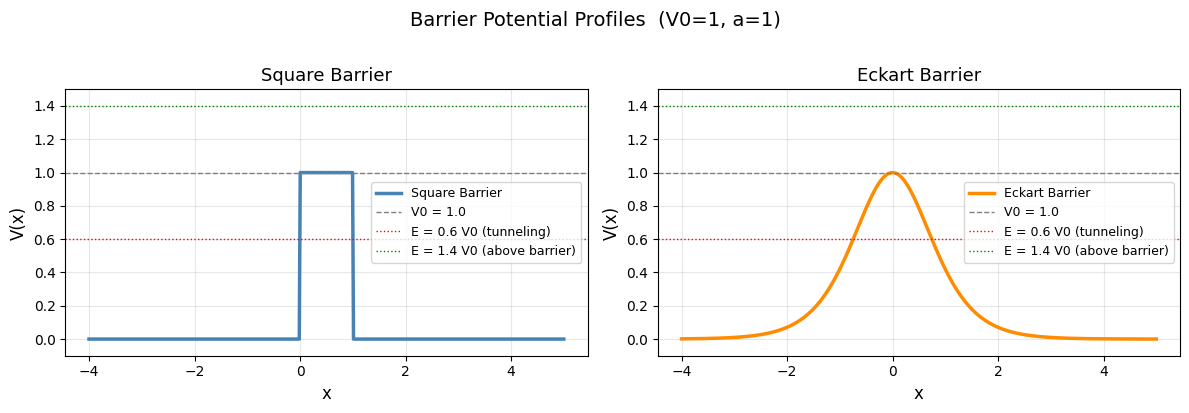

Potentials defined: V_square(x, V0, a)  |  V_eckart(x, V0, a)


In [51]:

# ============================================================
# CELL 2: Barrier Potential Functions
# ============================================================

def V_square(x, V0=1.0, a=1.0):
    """
    Square (rectangular) barrier.
    V(x) = V0  for  0 <= x <= a,  else 0.
    """
    return np.where((x >= 0) & (x <= a), V0, 0.0)


def V_eckart(x, V0=1.0, a=1.0):
    """
    Eckart (Poschl-Teller) barrier/potential.
    V(x) = V0 * sech^2(x/a)
    """
    return V0 / np.cosh(x / a)**2


# --- Plot both potentials for visual comparison ---
x = np.linspace(-4, 5, 500)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, V_func, label, color in zip(
        axes,
        [V_square, V_eckart],
        ['Square Barrier', 'Eckart Barrier'],
        ['steelblue', 'darkorange']):
    ax.plot(x, V_func(x, V0=1.0, a=1.0), color=color, lw=2.5, label=label)
    ax.axhline(1.0, ls='--', color='gray', lw=1, label='V0 = 1.0')
    ax.axhline(0.6, ls=':', color='red', lw=1, label='E = 0.6 V0 (tunneling)')
    ax.axhline(1.4, ls=':', color='green', lw=1, label='E = 1.4 V0 (above barrier)')
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('V(x)', fontsize=12)
    ax.set_title(label, fontsize=13)
    ax.legend(fontsize=9)
    ax.set_ylim(-0.1, 1.5)
    ax.grid(alpha=0.3)

plt.suptitle('Barrier Potential Profiles  (V0=1, a=1)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
print('Potentials defined: V_square(x, V0, a)  |  V_eckart(x, V0, a)')

In [52]:
# ============================================================
# CELL 3: Square Barrier -- Plane-Wave Scattering Solver
# Standard units: hbar=1, m=1  =>  k1=sqrt(2E), k2=sqrt(2(E-V0))
# Uses the exact piecewise analytical formula for all three regions.
# ============================================================

def square_scattering(E, V0=1.0, a=1.0, tol=1e-10):
    """

    Three cases handled separately:
      E < V0  : tunneling  -- kappa = sqrt(2(V0-E)), sinh formula
      E = V0  : threshold  -- linear psi inside, T=1/(1+V0*a^2/2)
      E > V0  : above barrier -- q = sqrt(2(E-V0)), sin formula

    Returns dict with T, R, t (complex amp), r (complex amp).
    """
    E = np.atleast_1d(np.array(E, dtype=float))
    T = np.zeros_like(E)
    R = np.zeros_like(E)
    t = np.full(E.shape, np.nan + 0j, dtype=complex)
    r = np.full(E.shape, np.nan + 0j, dtype=complex)

    # --- Case 1: E < V0  (tunneling) ---
    # k1 = sqrt(2E),  kappa = sqrt(2(V0-E))
    # T = 1 / [1 + V0^2 sinh^2(kappa*a) / (4E(V0-E))]
    mask_below = E < V0 - tol
    if np.any(mask_below):
        Eb    = E[mask_below]
        k1    = np.sqrt(2.0 * Eb)
        kappa = np.sqrt(2.0 * (V0 - Eb))
        denom = 1.0 + (V0**2 * np.sinh(kappa * a)**2) / (4.0 * Eb * (V0 - Eb))
        T[mask_below] = 1.0 / denom
        R[mask_below] = 1.0 - T[mask_below]
        # Approximate complex amplitude |t|=sqrt(T), phase not tracked
        t[mask_below] = np.sqrt(T[mask_below] + 0j)
        r[mask_below] = np.sqrt(R[mask_below] + 0j)

    # --- Case 2: E = V0  (threshold, linear wavefunction inside) ---
    # At E = V₀, the wavefunction inside the barrier is linear rather than exponential or sinusoidal
    # Psi= A+Bx
    # T = 1 / (1 + V0*a^2/2)  [exact for m=1, hbar=1]
    mask_equal = np.abs(E - V0) <= tol
    if np.any(mask_equal):
        T_eq = 1.0 / (1.0 + V0 * a**2 / 2.0)
        T[mask_equal] = T_eq
        R[mask_equal] = 1.0 - T_eq
        t[mask_equal] = np.sqrt(T_eq + 0j)
        r[mask_equal] = np.sqrt(1.0 - T_eq + 0j)

    # --- Case 3: E > V0  (above barrier, propagating wave inside) ---
    # k1 = sqrt(2E),  q = sqrt(2(E-V0))
    # T = 1 / [1 + V0^2 sin^2(q*a) / (4E(E-V0))]
    mask_above = E > V0 + tol
    if np.any(mask_above):
        Ea = E[mask_above]
        k1 = np.sqrt(2.0 * Ea)
        q  = np.sqrt(2.0 * (Ea - V0))
        denom = 1.0 + (V0**2 * np.sin(q * a)**2) / (4.0 * Ea * (Ea - V0))
        T[mask_above] = 1.0 / denom
        R[mask_above] = 1.0 - T[mask_above]
        t[mask_above] = np.sqrt(T[mask_above] + 0j)
        r[mask_above] = np.sqrt(R[mask_above] + 0j)

    return {'T': T, 'R': R, 't': t, 'r': r}


test_E = [0.5, 1.0, 1.5, 2.0]
print(f"{'E/V0':>8}  {'T':>10}  {'R':>10}  {'T+R':>10}")
for e in test_E:
    res = square_scattering(e, V0=1.0, a=1.0)
    T, R = res['T'][0], res['R'][0]
    print(f"{e:>8.2f}  {T:>10.6f}  {R:>10.6f}  {T+R:>10.6f}")

    E/V0           T           R         T+R
    0.50    0.419974    0.580026    1.000000
    1.00    0.666667    0.333333    1.000000
    1.50    0.809045    0.190955    1.000000
    2.00    0.891297    0.108703    1.000000


In [53]:
# ============================================================
# CELL 4: Eckart Barrier -- Exact Plane-Wave Scattering Solver
# V(x) = V0 sech^2(x/a).  Exact T via closed-form formula.
# hbar=1, m=1  =>  k = sqrt(2E)
# ============================================================

def eckart_scattering(E, V0=1.0, a=1.0):
    """
    Exact transmission probability for the Eckart (sech^2) barrier.
    Closed-form result (Landau & Lifshitz QM problem 23):

        T = sinh^2(pi*k*a) / [sinh^2(pi*k*a) + cosh^2(pi*sqrt(lam^2 - 1/4))]

    where:
        k   = sqrt(2*m*E) / hbar = sqrt(2*E)   [hbar=1, m=1]
        lam = sqrt(2*m*V0) * a / hbar = sqrt(2*V0) * a

    Parameters
    ----------
    E   : float or array
    V0  : float   -- barrier height
    a   : float   -- barrier width parameter

    Returns
    -------
    dict with 'T', 'R'
    """
    E = np.atleast_1d(np.array(E, dtype=float))

    # k = sqrt(2mE)/hbar  with m=1, hbar=1  =>  k = sqrt(2E)
    # prevents sqrt(0) at E = 0
    k = np.sqrt(2.0 * np.maximum(E, 1e-12))

    # Dimensionless barrier strength
    lam = 0.5 + np.sqrt(0.25 + 2.0 * V0 * a**2)

    sinh_k  = np.sinh(np.pi * k * a)
    arg_lam = lam**2 - 0.25

    with np.errstate(invalid='ignore'):
        cosh_lam = np.where(arg_lam >= 0,
                            np.cosh(np.pi * np.sqrt(arg_lam)),
                            np.cos( np.pi * np.sqrt(-arg_lam)))

    T = sinh_k**2 / (sinh_k**2 + cosh_lam**2)
    R = 1.0 - T

    return {'T': T, 'R': R, 't': None, 'r': None}


# Quick check
test_E = [0.5, 1.0, 1.5, 2.0]
print(f"{'E':>8}  {'T_eckart':>12}  {'R_eckart':>12}  {'T+R':>8}")
for e in test_E:
    res = eckart_scattering(e, V0=1.0, a=1.0)
    T, R = res['T'][0], res['R'][0]
    print(f"{e:>8.2f}  {T:>12.6f}  {R:>12.6f}  {T+R:>8.6f}")

       E      T_eckart      R_eckart       T+R
    0.50      0.115790      0.884210  1.000000
    1.00      0.639484      0.360516  1.000000
    1.50      0.928932      0.071068  1.000000
    2.00      0.985992      0.014008  1.000000


In [62]:

# ============================================================
# CELL 5: Scattering Dispatcher
# ============================================================

def scattering(E, model='square', V0=1.0, a=1.0):
    """
    Change 'model' to switch between barriers.

    Parameters
    ----------
    E     : float or array  -- particle energy
    model : str             -- 'square' or 'eckart'
    V0    : float           -- barrier height
    a     : float           -- barrier width

    Returns
    -------
    dict with keys 'T', 'R', 't', 'r', 'model'
    """
    if model == 'square':
        result = square_scattering(E, V0=V0, a=a)
    elif model == 'eckart':
        result = eckart_scattering(E, V0=V0, a=a)
    else:
        raise ValueError(f"Unknown model '{model}'. Choose 'square' or 'eckart'.")

    result['model'] = model
    return result


# --- Demonstrate: one line change switches models ---
E_test = np.array([0.5, 1.0, 1.5, 2.0])

print('MODEL = square')
for e in E_test:
    r = scattering(e, model='square', V0=1.0, a=1.0)
    print(f"  E={e:.1f}  T={r['T'][0]:.4f}  R={r['R'][0]:.4f}")

print('\nMODEL = eckart')
for e in E_test:
    r = scattering(e, model='eckart', V0=1.0, a=1.0)
    print(f"  E={e:.1f}  T={r['T'][0]:.4f}  R={r['R'][0]:.4f}")

MODEL = square
  E=0.5  T=0.4200  R=0.5800
  E=1.0  T=0.6667  R=0.3333
  E=1.5  T=0.8090  R=0.1910
  E=2.0  T=0.8913  R=0.1087

MODEL = eckart
  E=0.5  T=0.1158  R=0.8842
  E=1.0  T=0.6395  R=0.3605
  E=1.5  T=0.9289  R=0.0711
  E=2.0  T=0.9860  R=0.0140


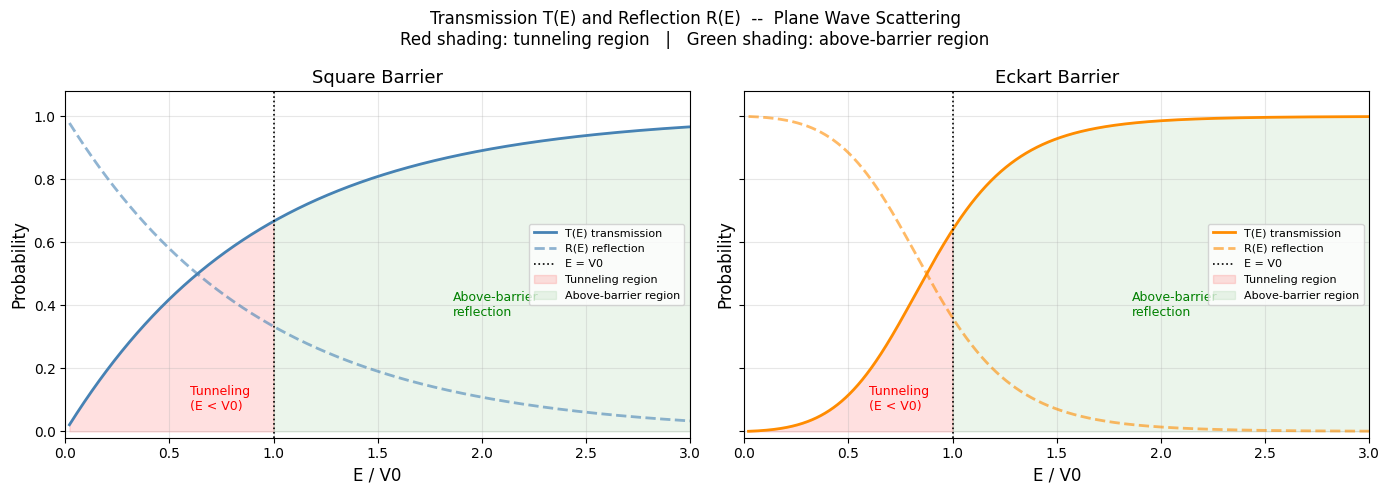

Figure saved as TR_curves.png


In [65]:

# ============================================================
# CELL 6: Plot T(E) and R(E) for Both Models
# Shows tunneling below V0, resonances above V0
# ============================================================

V0  = 1.0
a   = 1.0
E_arr = np.linspace(0.02, 3.0 * V0, 2000)

# Compute for both models
res_sq  = scattering(E_arr, model='square', V0=V0, a=a)
res_eck = scattering(E_arr, model='eckart', V0=V0, a=a)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, res, title, color in zip(
        axes,
        [res_sq, res_eck],
        ['Square Barrier', 'Eckart Barrier'],
        ['steelblue', 'darkorange']):

    ax.plot(E_arr / V0, res['T'], color=color,       lw=2,   label='T(E) transmission')
    ax.plot(E_arr / V0, res['R'], color=color,       lw=2,
            ls='--', alpha=0.6,                              label='R(E) reflection')
    ax.axvline(1.0, color='black', lw=1.2, ls=':',          label='E = V0')
    ax.fill_between(E_arr / V0, 0, res['T'],
                    where=(E_arr < V0), alpha=0.12, color='red',   label='Tunneling region')
    ax.fill_between(E_arr / V0, 0, res['T'],
                    where=(E_arr > V0), alpha=0.08, color='green', label='Above-barrier region')
    ax.set_xlabel('E / V0', fontsize=12)
    ax.set_ylabel('Probability', fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.set_xlim(0, 3)
    ax.legend(fontsize=8, loc='center right')
    ax.set_ylim(-0.02, 1.08)
    ax.grid(alpha=0.3)
    ax.annotate('Tunneling\n(E < V0)',
            xy=(0.2, 0.08), xycoords='axes fraction',
            fontsize=9, color='red')
    ax.annotate('Above-barrier\nreflection',
            xy=(0.62, 0.35), xycoords='axes fraction',
            fontsize=9, color='green')

plt.suptitle('Transmission T(E) and Reflection R(E)  --  Plane Wave Scattering\n'
             'Red shading: tunneling region   |   Green shading: above-barrier region',
             fontsize=12)
plt.tight_layout()
plt.savefig('TR_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as TR_curves.png')

=== a = 1.0  (standard barrier) ===
     n       E_res    E_res/V0       T_exact
     1      5.9348      5.9348    1.00000000
     2     20.7392     20.7392    1.00000000
     3     45.4132     45.4132    1.00000000
  --> First resonance at E/V0 = 5.93 is outside our E<3*V0 plot!

=== a = 3.0  (wider barrier -- resonances now visible in E/V0 < 4) ===
     n       E_res    E_res/V0       T_exact
     1      1.5483      1.5483    1.00000000
     2      3.1932      3.1932    1.00000000
     3      5.9348      5.9348    1.00000000
     4      9.7730      9.7730    1.00000000
     5     14.7078     14.7078    1.00000000


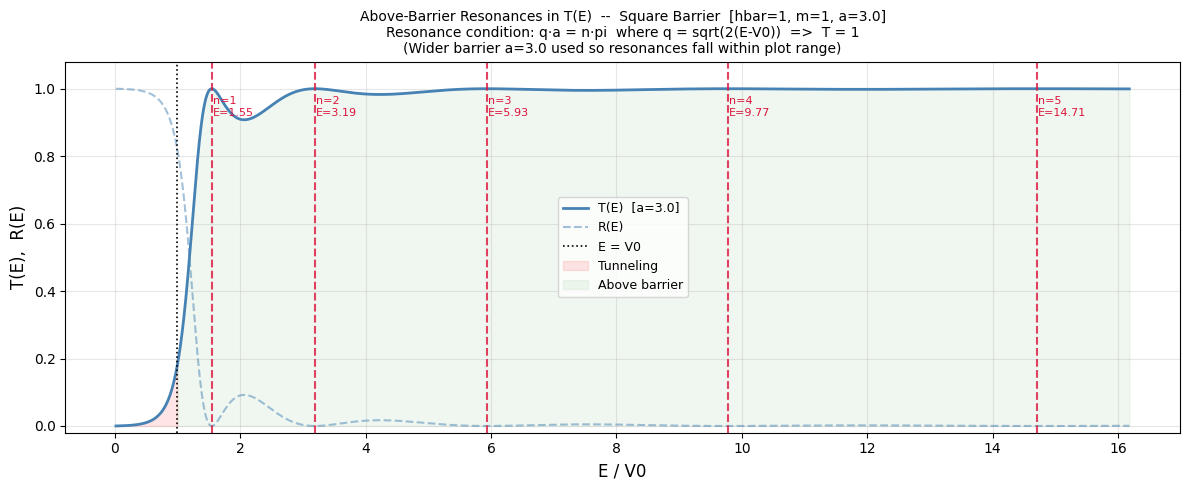


Note: for a=1 (rest of workbook), first resonance is at E/V0=5.93 -- off-plot.
Resonance cell uses a=3.0 purely for illustration of the T=1 resonance phenomenon.


In [56]:
# ============================================================
# CELL 7: Resonance Finder -- Square Barrier
# With hbar=1, m=1: q = sqrt(2(E-V0)), resonance at q*a = n*pi
# => E_n = V0 + (n*pi/a)^2 / 2
# a=1 puts first resonance at E/V0~5.93 -- outside plot range
# a=3 brings resonances into E/V0 < 4 for illustration purposes only
# rest of workbook uses a=1
# ============================================================
def resonance_energies(V0=1.0, a=1.0, n_max=5):
    """
    Exact resonance energies for square barrier with hbar=1, m=1.
    Condition: q * a = n * pi  where q = sqrt(2*(E-V0))  [m=1]
    => E_n = V0 + (n*pi/a)^2 / 2    for n = 1, 2, 3...
    """
    ns = np.arange(1, n_max + 1)
    return V0 + (ns * np.pi / a)**2 / 2.0

V0 = 1.0
a  = 1.0
# Fabry-Perot analogy: resonances occur when barrier width = integer number of half-wavelengths
# --- Show that with a=1 the resonances are far above our plot range ---
print('=== a = 1.0  (standard barrier) ===')
E_res_a1 = resonance_energies(V0=V0, a=1.0, n_max=3)
print(f"  {'n':>4}  {'E_res':>10}  {'E_res/V0':>10}  {'T_exact':>12}")
for n, Er in enumerate(E_res_a1, 1):
    res = square_scattering(Er, V0=V0, a=1.0)
    print(f"  {n:>4}  {Er:>10.4f}  {Er/V0:>10.4f}  {res['T'][0]:>12.8f}")
print('  --> First resonance at E/V0 = 5.93 is outside our E<3*V0 plot!')

# --- Use wider barrier a=3 so resonances appear in visible range ---
a_res = 3.0
print(f'\n=== a = {a_res}  (wider barrier -- resonances now visible in E/V0 < 4) ===')
E_res = resonance_energies(V0=V0, a=a_res, n_max=5)
print(f"  {'n':>4}  {'E_res':>10}  {'E_res/V0':>10}  {'T_exact':>12}")
for n, Er in enumerate(E_res, 1):
    res = square_scattering(Er, V0=V0, a=a_res)
    print(f"  {n:>4}  {Er:>10.4f}  {Er/V0:>10.4f}  {res['T'][0]:>12.8f}")

# --- Plot T(E) showing resonances for a_res=3 ---
E_arr = np.linspace(0.02, E_res[4] * 1.1, 4000)
res_sq = square_scattering(E_arr, V0=V0, a=a_res)

plt.figure(figsize=(12, 5))
plt.plot(E_arr / V0, res_sq['T'], color='steelblue', lw=2, label=f'T(E)  [a={a_res}]')
plt.plot(E_arr / V0, res_sq['R'], color='steelblue', lw=1.5,
         ls='--', alpha=0.5, label='R(E)')

for n, Er in enumerate(E_res[:5], 1):
    plt.axvline(Er / V0, color='crimson', lw=1.5, ls='--', alpha=0.8)
    plt.text(Er / V0 + 0.02, 0.92, f'n={n}\nE={Er:.2f}', fontsize=8, color='crimson')

plt.axvline(1.0, color='black', lw=1.2, ls=':', label='E = V0')
plt.fill_between(E_arr / V0, 0, res_sq['T'],
                 where=(E_arr < V0), alpha=0.1, color='red', label='Tunneling')
plt.fill_between(E_arr / V0, 0, res_sq['T'],
                 where=(E_arr > V0), alpha=0.06, color='green', label='Above barrier')

plt.xlabel('E / V0', fontsize=12)
plt.ylabel('T(E),  R(E)', fontsize=12)
plt.title(f'Above-Barrier Resonances in T(E)  --  Square Barrier  [hbar=1, m=1, a={a_res}]\n'
          f'Resonance condition: q·a = n·pi  where q = sqrt(2(E-V0))  =>  T = 1\n'
          f'(Wider barrier a={a_res} used so resonances fall within plot range)',
          fontsize=10)
plt.legend(fontsize=9)
plt.grid(alpha=0.3)
plt.ylim(-0.02, 1.08)
plt.tight_layout()
plt.savefig('resonances.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nNote: for a=1 (rest of workbook), first resonance is at E/V0={E_res_a1[0]/V0:.2f} -- off-plot.')
print(f'Resonance cell uses a={a_res} purely for illustration of the T=1 resonance phenomenon.')

/tmp/ipykernel_9575/3867125036.py:22: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.axhline(1e-10, color='gray', ls='--', lw=1, label='1e-10 reference')


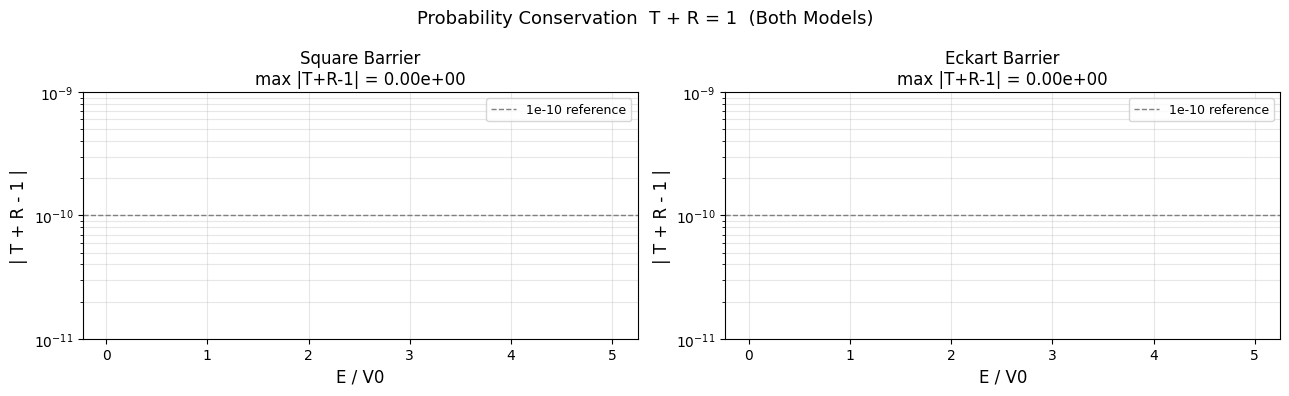

Conservation errors:
  square: max error = 0.00e+00  mean error = 0.00e+00
  eckart: max error = 0.00e+00  mean error = 0.00e+00


In [68]:

# ============================================================
# CELL 8: Conservation Check  T + R = 1
# Essential verification for both models across all energies
# ============================================================

V0  = 1.0
a   = 1.0
E_check = np.linspace(0.02, 5.0, 5000)

errors = {}
for model in ['square', 'eckart']:
    res   = scattering(E_check, model=model, V0=V0, a=a)
    TR    = res['T'] + res['R']
    err   = np.abs(TR - 1.0)
    errors[model] = err

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, model, color in zip(axes, ['square', 'eckart'], ['steelblue', 'darkorange']):
    ax.semilogy(E_check / V0, errors[model], color=color, lw=1.5)
    ax.axhline(1e-10, color='gray', ls='--', lw=1, label='1e-10 reference')
    ax.set_xlabel('E / V0', fontsize=12)
    ax.set_ylabel('| T + R - 1 |', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3, which='both')
    max_err = errors[model].max()
    ax.set_title(f"{model.capitalize()} Barrier\nmax |T+R-1| = {max_err:.2e}", fontsize=12)

plt.suptitle('Probability Conservation  T + R = 1  (Both Models)', fontsize=13)
plt.tight_layout()
plt.savefig('conservation.png', dpi=150, bbox_inches='tight')
plt.show()

print('Conservation errors:')
for model in ['square', 'eckart']:
    print(f"  {model}: max error = {errors[model].max():.2e}  mean error = {errors[model].mean():.2e}")

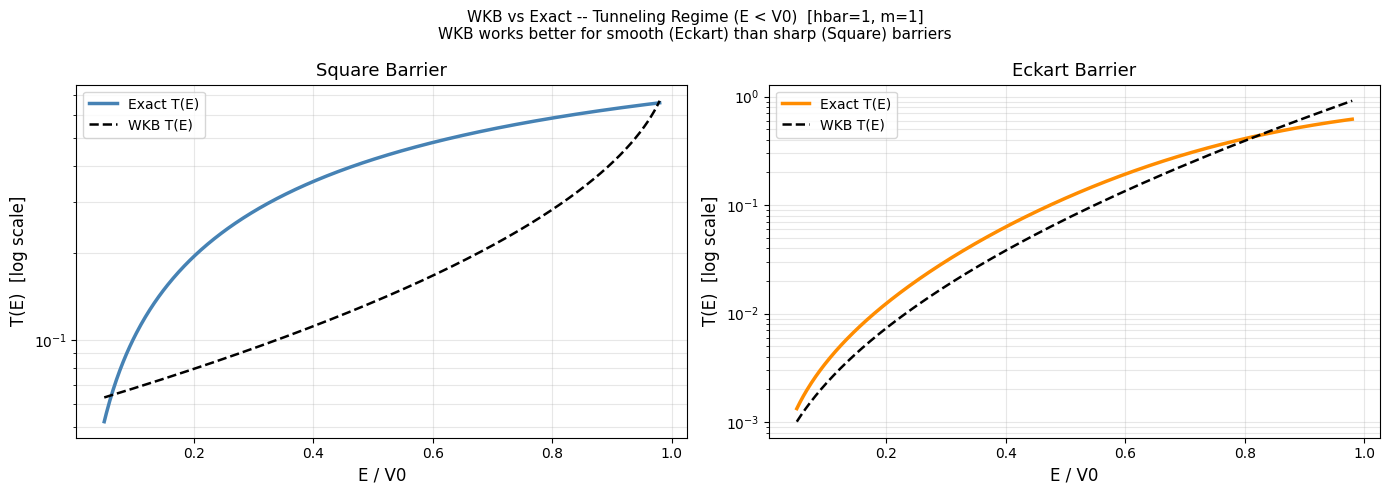

In [69]:
# ============================================================
# CELL 9: WKB (Wentzel-Kramers-Brillouin) Approximation vs Exact
# WKB: T_wkb = exp(-2 * integral kappa(x) dx) [from x1 to x2]
# kappa(x) = sqrt(2m(V(x)-E))/hbar = sqrt(2(V(x)-E))  [m=1, hbar=1]

# ============================================================
def wkb_T(E, V_func, V0=1.0, a=1.0, x_lo=-3, x_hi=4, n_pts=2000):
    """
    WKB tunneling probability for arbitrary barrier V_func.
    kappa(x) = sqrt(2*(V(x)-E))  [hbar=1, m=1]
    T_WKB = exp(-2 * integral kappa dx)
    """
    E = np.atleast_1d(np.array(E, dtype=float))
    T_wkb = np.zeros_like(E)
    x = np.linspace(x_lo, x_hi, n_pts)
    V = V_func(x, V0=V0, a=a)
    for i, Ei in enumerate(E):
        if Ei >= V0:
          # WKB gives no exponential suppression above barrier but does not predict T=1
          # Above-barrier reflection requires full quantum treatment; WKB not valid here
          T_wkb[i] = np.nan  # explicitly mark as outside WKB validity
          continue
        # kappa = sqrt(2m(V-E)) with m=1, hbar=1
        integrand = np.sqrt(2.0 * np.maximum(V - Ei, 0.0)) # correctly zeros out regions where V < E (classically allowed), so only the forbidden region contributes
        integral  = np.trapezoid(integrand, x)
        T_wkb[i]  = np.exp(-2.0 * integral)
    return T_wkb

V0 = 1.0
a  = 1.0
E_tun = np.linspace(0.05, 0.98 * V0, 500)

T_sq_exact  = square_scattering(E_tun, V0=V0, a=a)['T']
T_sq_wkb    = wkb_T(E_tun, V_square, V0=V0, a=a)

T_eck_exact = eckart_scattering(E_tun, V0=V0, a=a)['T']
T_eck_wkb   = wkb_T(E_tun, V_eckart, V0=V0, a=a)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, T_exact, T_wkb, title, color in zip(
        axes,
        [T_sq_exact, T_eck_exact],
        [T_sq_wkb,   T_eck_wkb],
        ['Square Barrier', 'Eckart Barrier'],
        ['steelblue', 'darkorange']):
    ax.semilogy(E_tun / V0, T_exact, color=color, lw=2.5, label='Exact T(E)')
    ax.semilogy(E_tun / V0, T_wkb,   color='black', lw=1.8, ls='--', label='WKB T(E)')
    ax.set_xlabel('E / V0', fontsize=12)
    ax.set_ylabel('T(E)  [log scale]', fontsize=12)
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3, which='both')
plt.suptitle('WKB vs Exact -- Tunneling Regime (E < V0)  [hbar=1, m=1]\n'
             'WKB works better for smooth (Eckart) than sharp (Square) barriers',
             fontsize=11)
plt.tight_layout()
plt.savefig('WKB_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

Central energy E0 = k0^2/2 = 0.320   V0 = 1.00
E0/V0 = 0.320  -->  tunneling

Gaussian packet average transmission  = 0.2945
Plane wave T at E0: T(E0) = 0.2932


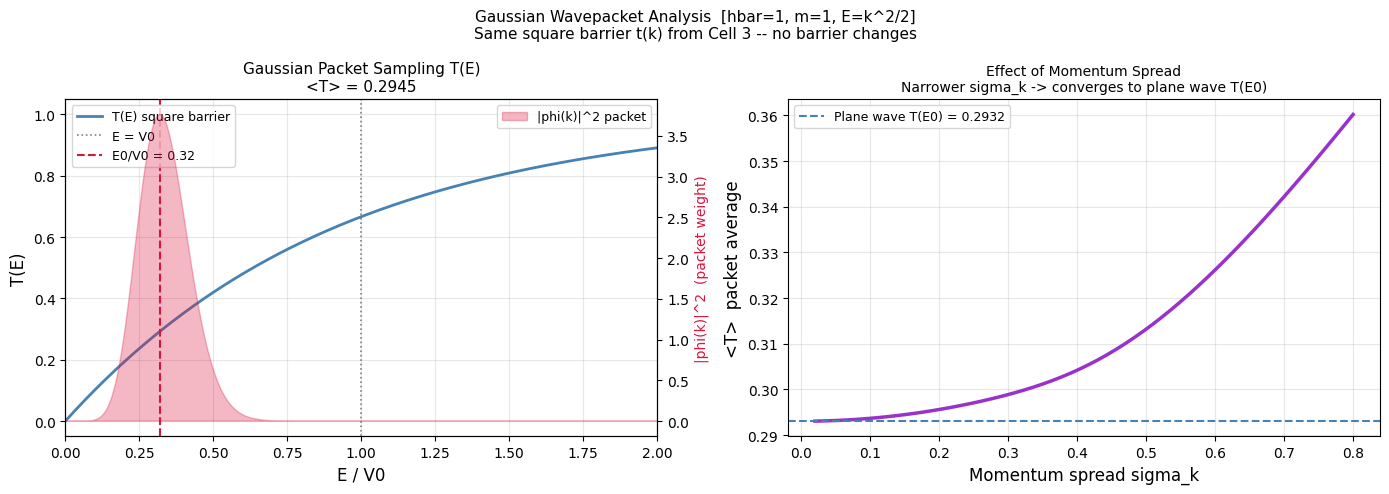

In [59]:
# ============================================================
# CELL 10: Gaussian Wavepacket -- Momentum-Space Analysis
# hbar=1, m=1  =>  E = k^2 / (2m) = k^2 / 2
# a Gaussian wavepacket is a superposition of plane waves weighted by a Gaussian in k-space
#This is more physical than a plane wave since real particles always have some momentum spread.
# As sigma_k→0 the packet narrows to a plane wave and ⟨T⟩→T(E0).
# ============================================================
# --- Packet parameters ---
k0      = 0.8          # central wavenumber
sigma_k = 0.15         # width in k-space
V0      = 1.0
a       = 1.0

# Central energy: E0 = k0^2 / 2  [hbar=1, m=1]
E0 = k0**2 / 2.0
print(f'Central energy E0 = k0^2/2 = {E0:.3f}   V0 = {V0:.2f}')
print(f'E0/V0 = {E0/V0:.3f}  -->  {"tunneling" if E0 < V0 else "above barrier"}')

# --- k grid ---
# Gaussian normalization integral is very slightly off if k0 is very small
# For k0 = 0.8 and sigma_k = 0.15 the packet has negligible weight near k = 0.01
Nk    = 4096
k_arr = np.linspace(0.01, 4.0, Nk)

# --- Step 1: Gaussian in k-space ---
phi_k = np.exp(-(k_arr - k0)**2 / (2.0 * sigma_k**2))
phi_k /= np.sqrt(np.trapezoid(np.abs(phi_k)**2, k_arr))  # normalize

# --- dispersion relation  E = k^2/2  [hbar=1, m=1] ---
E_arr = k_arr**2 / 2.0

# Get T(k) and t(k) from square barrier solver
res = square_scattering(E_arr, V0=V0, a=a)
T_k = res['T']
t_k = res['t']

# --- Step 3: Transmitted packet in k-space ---
phi_trans_k = phi_k * t_k

# --- Step 4: Total average transmission  ---
weights = np.abs(phi_k)**2
T_avg   = np.trapezoid(weights * T_k, k_arr) / np.trapezoid(weights, k_arr)
print(f'\nGaussian packet average transmission  = {T_avg:.4f}')
print(f'Plane wave T at E0: T(E0) = {T_k[np.argmin(np.abs(E_arr - E0))]:.4f}')

# --- Plot 1: phi(k)^2 overlaid on T(E) ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax  = axes[0]
ax2 = ax.twinx()
ax.plot(E_arr / V0, T_k, color='steelblue', lw=2, label='T(E) square barrier')
ax2.fill_between(E_arr / V0, np.abs(phi_k)**2,
                 color='crimson', alpha=0.3, label='|phi(k)|^2 packet')
ax2.set_ylabel('|phi(k)|^2  (packet weight)', color='crimson', fontsize=10)
ax.axvline(1.0,      color='gray',    ls=':', lw=1.2, label='E = V0')
ax.axvline(E0 / V0,  color='crimson', ls='--', lw=1.5, label=f'E0/V0 = {E0/V0:.2f}')
ax.set_xlabel('E / V0', fontsize=12)
ax.set_ylabel('T(E)', fontsize=12)
ax.set_title(f'Gaussian Packet Sampling T(E)\n<T> = {T_avg:.4f}', fontsize=11)
ax.legend(fontsize=9, loc='upper left')
ax2.legend(fontsize=9, loc='upper right')
ax.set_xlim(0, 2.0)
ax.grid(alpha=0.3)

# --- Plot 2: <T> vs packet width ---
sigma_vals = np.linspace(0.02, 0.8, 60)
T_avgs = []
for sg in sigma_vals:
    ph = np.exp(-(k_arr - k0)**2 / (2.0 * sg**2))
    wt = np.abs(ph)**2
    T_avgs.append(np.trapezoid(wt * T_k, k_arr) / np.trapezoid(wt, k_arr))
ax = axes[1]
T_at_E0 = T_k[np.argmin(np.abs(E_arr - E0))]
ax.plot(sigma_vals, T_avgs, color='darkorchid', lw=2.5)
ax.axhline(T_at_E0, color='steelblue', ls='--', lw=1.5,
           label=f'Plane wave T(E0) = {T_at_E0:.4f}')
ax.set_xlabel('Momentum spread sigma_k', fontsize=12)
ax.set_ylabel('<T>  packet average', fontsize=12)
ax.set_title('Effect of Momentum Spread\nNarrower sigma_k -> converges to plane wave T(E0)', fontsize=10)
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.suptitle('Gaussian Wavepacket Analysis  [hbar=1, m=1, E=k^2/2]\n'
             'Same square barrier t(k) from Cell 3 -- no barrier changes', fontsize=11)
plt.tight_layout()
plt.savefig('gaussian_packet.png', dpi=150, bbox_inches='tight')
plt.show()
# The second plot visually proves that the plane wave result is the limiting case of the wavepacket treatment, not a separate theory.

  QUANTUM BARRIER SCATTERING -- MASTER PARAMETER BLOCK


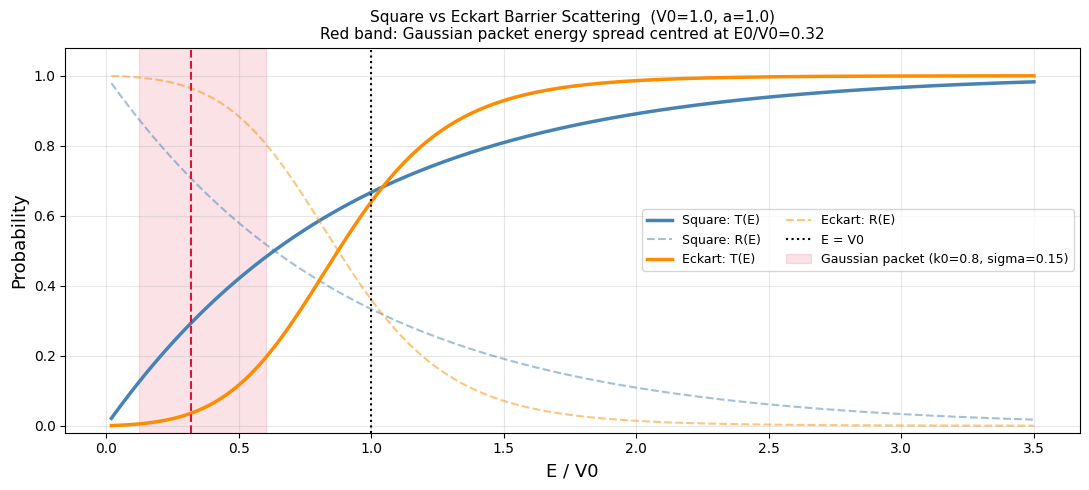


Parameters:  V0=1.0  a=1.0  k0=0.8  sigma_k=0.15
    E/V0    T_square    T_eckart           Regime
    0.30    0.277111    0.030362        tunneling
    0.60    0.480727    0.193033        tunneling
    1.00    0.666862    0.640024       at barrier
    1.50    0.808937    0.928810    above barrier
    2.00    0.891250    0.985975    above barrier
    3.00    0.966691    0.999157    above barrier


In [70]:
# ============================================================
# CELL 11: MASTER RUNNER -- Change Parameters Here Only
# Adjust V0, a, k0, sigma_k here. All cells update automatically.
# ============================================================

print('=' * 60)
print('  QUANTUM BARRIER SCATTERING -- MASTER PARAMETER BLOCK')
print('=' * 60)

# ---- CHANGE THESE ----
V0      = 1.0    # barrier height (energy units)
a       = 1.0    # barrier width (length units)
k0      = 0.8    # Gaussian packet central wavenumber
sigma_k = 0.15   # Gaussian packet momentum spread
# ----------------------

# Central energy: E0 = k0^2/2  [hbar=1, m=1]
E0    = k0**2 / 2.0
E_arr = np.linspace(0.02, 3.5 * V0, 3000)

# --- Summary: T(E) both models on one plot ---
res_sq  = scattering(E_arr, model='square', V0=V0, a=a)
res_eck = scattering(E_arr, model='eckart', V0=V0, a=a)

plt.figure(figsize=(11, 5))
plt.plot(E_arr / V0, res_sq['T'],  color='steelblue',  lw=2.5, label='Square: T(E)')
plt.plot(E_arr / V0, res_sq['R'],  color='steelblue',  lw=1.5, ls='--', alpha=0.5, label='Square: R(E)')
plt.plot(E_arr / V0, res_eck['T'], color='darkorange',  lw=2.5, label='Eckart: T(E)')
plt.plot(E_arr / V0, res_eck['R'], color='darkorange',  lw=1.5, ls='--', alpha=0.5, label='Eckart: R(E)')
plt.axvline(1.0, color='black', ls=':', lw=1.5, label='E = V0')

# Mark Gaussian packet energy range
# FIXED: E = k^2/2 with hbar=1, m=1 (not k^2)
k_range = np.linspace(k0 - 2*sigma_k, k0 + 2*sigma_k, 100)
E_range = k_range**2 / 2.0
plt.axvspan(E_range.min() / V0, E_range.max() / V0,
            alpha=0.12, color='crimson', label=f'Gaussian packet (k0={k0}, sigma={sigma_k})')
plt.axvline(E0 / V0, color='crimson', ls='--', lw=1.5)

plt.xlabel('E / V0', fontsize=13)
plt.ylabel('Probability', fontsize=13)
plt.title(f'Square vs Eckart Barrier Scattering  (V0={V0}, a={a})\n'
          f'Red band: Gaussian packet energy spread centred at E0/V0={E0/V0:.2f}',
          fontsize=11)
plt.legend(fontsize=9, ncol=2)
plt.ylim(-0.02, 1.08)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('master_summary.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Print summary table ---
# FIXED: interpolate from pre-computed res_sq/res_eck instead of calling solver 12 times
print(f'\nParameters:  V0={V0}  a={a}  k0={k0}  sigma_k={sigma_k}')
print(f"{'E/V0':>8}  {'T_square':>10}  {'T_eckart':>10}  {'Regime':>15}")
for ev in [0.3, 0.6, 1.0, 1.5, 2.0, 3.0]:
    idx    = np.argmin(np.abs(E_arr - ev * V0))
    ts     = res_sq['T'][idx]
    te     = res_eck['T'][idx]
    # FIXED: float equality replaced with np.isclose
    regime = 'tunneling' if ev < 1.0 else ('at barrier' if np.isclose(ev, 1.0) else 'above barrier')
    print(f"{ev:>8.2f}  {ts:>10.6f}  {te:>10.6f}  {regime:>15}")